# 0. Vetorização e Treinamento do Modelo

Esquema obrigatório de treinamento: `Titulo`, `Noticia`, `Autor`, `Classe`. Na inferência: `Titulo`, `Noticia`, `Autor`. Os nomes são exatos; colunas ausentes ou duplicadas interrompem a execução antes da vetorização. Título e autor podem conter valores ausentes, mas suas colunas devem existir. A classe é somente o alvo e não entra nas features. A validação é salva dentro de cada pipeline.


**Modo padrão: exploratório**, com a base original e aviso de possível contaminação por textos/autores de checagem. A ficha não bloqueia este modo e não é alterada. Não se mistura a pequena parcela revisada com a base original. Resultados ficam em `v1_texto_autor_exploratorio`. Para treinar somente com entradas integralmente revisadas, altere `REVIEW_MODE` para `strict`; nesse modo a ficha completa é obrigatória e os artefatos ficam em `v1_texto_autor_auditado`.


Treinamento com Titulo + Noticia em TF-IDF e Autor em one-hot encoding, ajustados somente no treino. Rótulos: 0 = Fake, 1 = Real. Autores ausentes ou preenchidos com datas recebem autor_desconhecido; autores novos são aceitos na inferência. A base original é carregada porque o CSV de duas colunas não preserva Autor.

Este experimento v1 ainda exige a auditoria do notebook 04. Autor pode representar um atalho de fonte; o desempenho em autores/fontes inéditos deve ser avaliado antes de concluir generalização. Resultados antigos foram removidos e os novos artefatos usam diretório próprio.

In [1]:
from pathlib import Path
import sys
for base in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    module_dir = base / "notebooks/v1_baseline"
    if (module_dir / "baseline_features.py").is_file():
        sys.path.insert(0, str(module_dir))
        break
else:
    raise FileNotFoundError("Execute dentro do projeto.")
import importlib
import baseline_features
importlib.reload(baseline_features)
from baseline_features import make_features, load_dataset, project_root, FEATURE_COLUMNS, LABEL_NAMES
from sklearn.pipeline import Pipeline
ROOT = project_root()
REVIEW_MODE = "exploratory"  # Troque para "strict" somente após concluir a ficha.
RUN_NAME = "v1_texto_autor_exploratorio" if REVIEW_MODE == "exploratory" else "v1_texto_autor_auditado"
ARTIFACT_DIR = ROOT / "models" / RUN_NAME
REPORT_DIR = ROOT / "reports" / RUN_NAME
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
from evaluation_plots import plot_class_distribution, plot_evaluation
GRAPH_DIR = REPORT_DIR / "graficos/regressao_logistica"


# 2. Carregamento do dataset com os três atributos

In [2]:
df = load_dataset(ROOT, review_mode=REVIEW_MODE)
print("Modo da execução:", REVIEW_MODE)
print("Registros:", len(df))
display(df[FEATURE_COLUMNS + ["Classe"]].head())


C:\Users\LAISA\OneDrive\Documentos\identificador-de-fake-news\notebooks\v1_baseline\baseline_features.py:189: UserWarning: EXPERIMENTO EXPLORATÓRIO: base original não auditada integralmente. Textos e autores podem conter pistas da checagem. As métricas não comprovam generalização externa.
  return load_exploratory_dataset(root)


Modo da execução: exploratory
Registros: 11902


,Titulo,Noticia,Autor,Classe
0,\n\nPapa Francisco foi preso sob acusação de t...,apagão vaticano papar presar acusação tráfico ...,\nEdgard Matsuki,0
1,Equador prepara cova coletiva para mortos por ...,o governar equador anunciar preparar cova cole...,27/03/2020 18h25,1
2,Air France voltará a operar voo direto Pequim-...,o companhia air france operar voar direto pequ...,07/08/2020 13h42,1
3,Marfrig intensifica venda de carne do Brasil a...,o marfrig global foods retomar vender carnar b...,27/04/2020 14h53,1
4,As parciais das eleições de 2014 alternaram ma...,o assunto voltar o compartilhar rede social ju...,Gilmar Lopes,0


# 3. Divisão em Treino e Teste

Amostras de Treino: 9521
Amostras de Teste: 2381


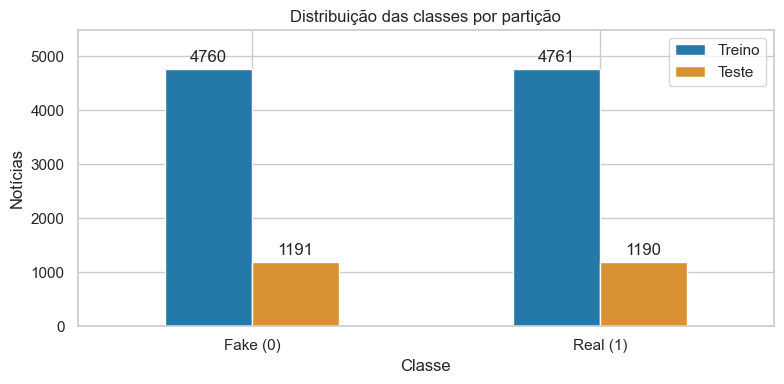

In [3]:
X = df[FEATURE_COLUMNS]
y = df["Classe"].astype(int)

# Divisão 80% Treino e 20% Teste mantendo proporção de classes (stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Amostras de Treino: {len(X_train)}")
print(f"Amostras de Teste: {len(X_test)}")
plot_class_distribution(y_train, y_test, GRAPH_DIR)


# 4. TF-IDF do texto + codificação categórica do autor

In [4]:
features = make_features(max_features=5000)
X_train_tfidf = features.fit_transform(X_train)
X_test_tfidf = features.transform(X_test)
print("Matrizes texto + autor:", X_train_tfidf.shape, X_test_tfidf.shape)


Matrizes texto + autor: (9521, 6300) (2381, 6300)


# 5. Treinamento da Regressão Logística

In [5]:
modelo = LogisticRegression(max_iter=1000, random_state=42)
modelo.fit(X_train_tfidf, y_train)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

# 6. Avaliação do Desempenho

Gráficos: matrizes de confusão em contagens e percentuais por classe, métricas, ROC, precisão–recall e erros por direção. Fake é a classe de interesse nas curvas; o encoding continua 0=Fake, 1=Real. As figuras são calculadas no teste e exportadas em PNG/SVG. Não representam validação externa.

              precision    recall  f1-score   support

        Fake       0.99      0.97      0.98      1191
        Real       0.97      0.99      0.98      1190

    accuracy                           0.98      2381
   macro avg       0.98      0.98      0.98      2381
weighted avg       0.98      0.98      0.98      2381



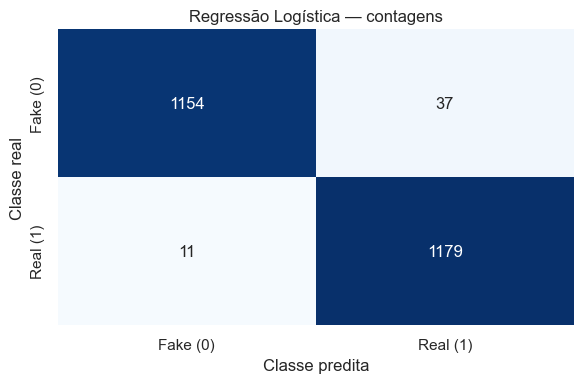

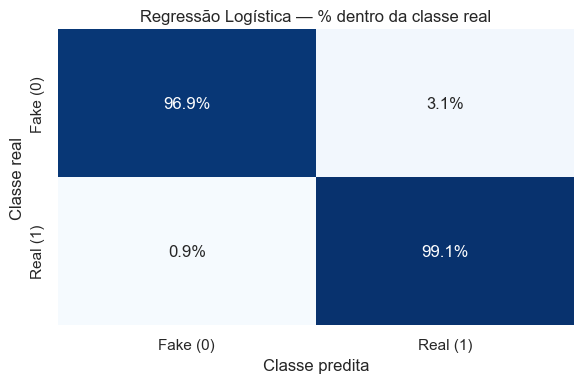

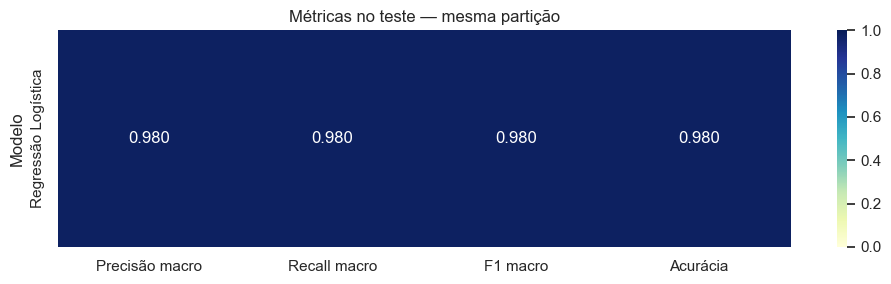

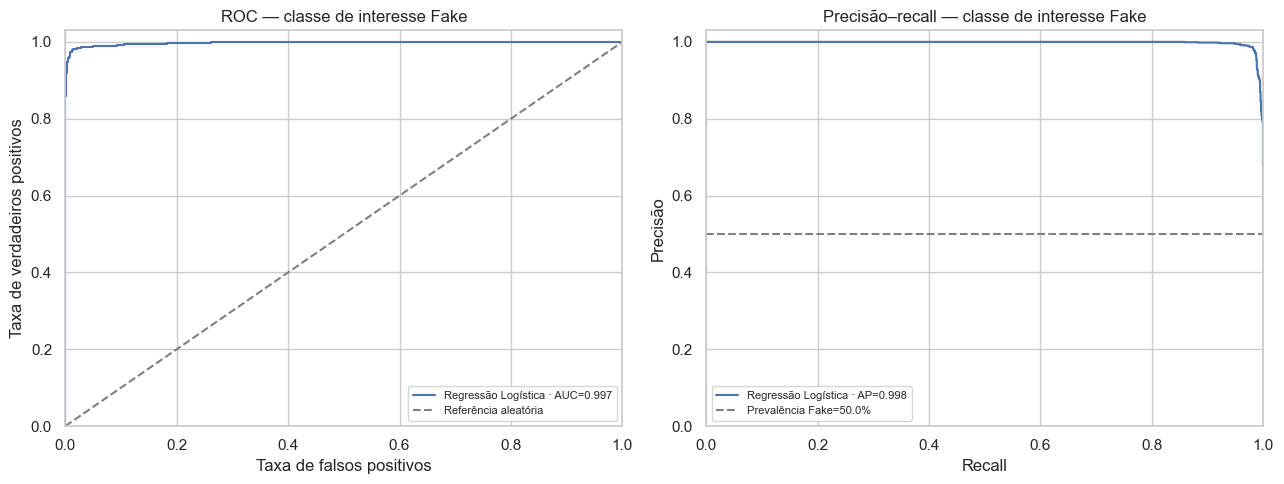

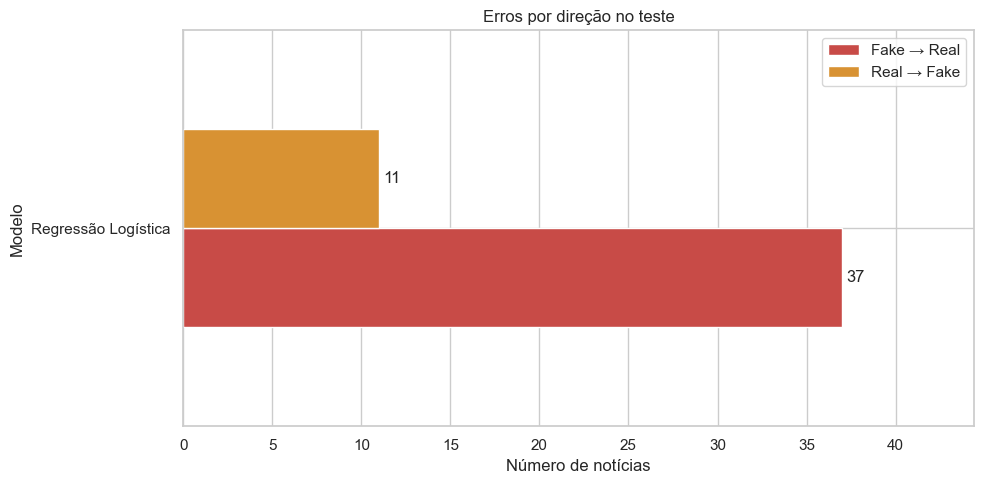

In [6]:
y_pred = modelo.predict(X_test_tfidf)
print(classification_report(y_test, y_pred, labels=[0, 1], target_names=["Fake", "Real"], zero_division=0))
plot_evaluation({"Regressão Logística": modelo}, X_test_tfidf, y_test, GRAPH_DIR)


# 7. Resultados e artefatos
As métricas abaixo são calculadas nesta execução. A dimensão total inclui vocabulário textual e autores aprendidos no treino. Não compare com números antigos sem considerar a mudança de entrada e preparação.

In [7]:
import json
import joblib
from sklearn.metrics import accuracy_score, f1_score
pipeline = Pipeline([("features", features), ("clf", modelo)])
results = {"feature_columns": FEATURE_COLUMNS, "label_names": LABEL_NAMES,
           "train_n": len(X_train), "test_n": len(X_test),
           "n_features": X_train_tfidf.shape[1], "review": dict(df.attrs),
           "accuracy": float(accuracy_score(y_test, y_pred)),
           "f1_macro": float(f1_score(y_test, y_pred, average="macro"))}
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump({"pipeline": pipeline, "feature_columns": FEATURE_COLUMNS, "label_names": LABEL_NAMES, "review": dict(df.attrs)},
            ARTIFACT_DIR / "regressao_logistica.joblib")
(REPORT_DIR / "metrics_regressao_logistica.json").write_text(
    json.dumps(results, indent=2, ensure_ascii=False), encoding="utf-8")
print(results)


{'feature_columns': ['Titulo', 'Noticia', 'Autor'], 'label_names': {0: 'Fake', 1: 'Real'}, 'train_n': 9521, 'test_n': 2381, 'n_features': 6300, 'review': {'review_mode': 'exploratory', 'review_policy': 'base_original_sem_aprovacao_integral', 'raw_sha256': '00e70d8173fc6b06fe0a387bb7aa8078d2e64d69df86b8971817baa901ed874a'}, 'accuracy': 0.9798404031919362, 'f1_macro': 0.9798381804402407}


# 8. Diagnóstico Final da Avaliação

### Análise dos Resultados e Próximos Passos

A célula abaixo consolida as métricas calculadas nesta execução, a distribuição dos erros e a comparação com um baseline que sempre prevê a classe mais frequente no treino. Os valores são gerados a partir de `y_test` e `y_pred`, sem reutilizar resultados do benchmark.

A avaliação utiliza o limiar padrão do modelo. O diagnóstico descreve o desempenho interno e as limitações; não representa validação externa nem comprova veracidade factual. Execute as etapas anteriores antes desta célula.

In [8]:
import numpy as np
from IPython.display import Markdown, display
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, confusion_matrix

# 1. Consolidação das métricas e dos erros desta execução
valores_precisao, valores_recall, valores_f1, valores_suporte = precision_recall_fscore_support(
    y_test, y_pred, labels=[0, 1], average=None, zero_division=0
)

# Garantir arrays por classe antes de acessar os índices 0 e 1
precisao_classes = np.asarray(valores_precisao, dtype=float)
recall_classes = np.asarray(valores_recall, dtype=float)
f1_classes = np.asarray(valores_f1, dtype=float)
suporte_classes = np.asarray(valores_suporte, dtype=float)
for valores in [precisao_classes, recall_classes, f1_classes, suporte_classes]:
    if valores.shape != (2,):
        raise ValueError("Esperadas métricas individuais para Fake (0) e Real (1).")
matriz = confusion_matrix(y_test, y_pred, labels=[0, 1])
fake_correta, fake_como_real, real_como_fake, real_correta = matriz.ravel()
total_teste = len(y_test)
erros_totais = int(fake_como_real + real_como_fake)
acuracia = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, labels=[0, 1], average="macro", zero_division=0)

# 2. Baseline de referência: classe mais frequente apenas no treino
classe_majoritaria = int(y_train.value_counts().idxmax())
pred_baseline = np.full(total_teste, classe_majoritaria)
acuracia_baseline = accuracy_score(y_test, pred_baseline)
f1_baseline = f1_score(y_test, pred_baseline, labels=[0, 1], average="macro", zero_division=0)

# 3. Comparação descritiva entre treino e teste, sem novo ajuste
pred_treino = modelo.predict(X_train_tfidf)
f1_treino = f1_score(y_train, pred_treino, labels=[0, 1], average="macro", zero_division=0)
diferenca_f1 = f1_treino - f1_macro
iteracoes = int(np.max(modelo.n_iter_))
limite_iteracoes = int(modelo.get_params()["max_iter"])

# 4. Interpretação da direção dos erros
if fake_como_real > real_como_fake:
    comportamento_erros = "Houve mais notícias falsas classificadas como reais do que notícias reais classificadas como falsas."
elif real_como_fake > fake_como_real:
    comportamento_erros = "Houve mais notícias reais classificadas como falsas do que notícias falsas classificadas como reais."
else:
    comportamento_erros = "As duas direções apresentaram o mesmo número absoluto de erros."

if iteracoes >= limite_iteracoes:
    observacao_convergencia = "O ajuste atingiu o limite de iterações. Confira os avisos do treinamento e a convergência antes de interpretar os resultados."
else:
    observacao_convergencia = "O ajuste terminou antes do limite de iterações. Isso não substitui a inspeção de eventuais avisos emitidos pelo treinamento."

modo_exploratorio = df.attrs.get("review_mode", REVIEW_MODE) == "exploratory"
observacao_auditoria = (
    "Esta execução utiliza a base original em modo exploratório. Textos e autores ainda podem conter pistas de checagem; a revisão integral permanece pendente."
    if modo_exploratorio else
    "Esta execução utiliza entradas aprovadas na ficha de revisão. A revisão não elimina automaticamente o viés de fonte nem relações entre alegações."
)

# 5. Exibição do diagnóstico no próprio notebook
diagnostico = f"""## Diagnóstico da Regressão Logística

### 1. Desempenho Geral

O modelo foi ajustado em **{len(y_train):,} amostras de treino** e avaliado em **{total_teste:,} amostras de teste**, utilizando **{X_train_tfidf.shape[1]:,} atributos** de título + notícia + autor.

* **Acurácia:** {acuracia:.2%}.
* **F1-Macro:** {f1_macro:.4f}.
* **Acertos:** {total_teste - erros_totais:,} notícias.
* **Erros totais:** {erros_totais:,} notícias ({erros_totais / total_teste:.2%} do teste).

### 2. Desempenho por Classe

| Classe | Precisão | Recall | F1-Score | Amostras |
|---|---:|---:|---:|---:|
| Fake (0) | {precisao_classes[0]:.4f} | {recall_classes[0]:.4f} | {f1_classes[0]:.4f} | {int(suporte_classes[0])} |
| Real (1) | {precisao_classes[1]:.4f} | {recall_classes[1]:.4f} | {f1_classes[1]:.4f} | {int(suporte_classes[1])} |

O recall de Fake mede a proporção de notícias falsas reconhecidas como falsas. A precisão de Fake mede a proporção de acertos entre as notícias classificadas como falsas. O F1-Macro atribui o mesmo peso às duas classes, independentemente do suporte.

### 3. Diagnóstico dos Erros

* **Fake corretamente classificada:** {int(fake_correta)}.
* **Fake classificada como Real:** {int(fake_como_real)}.
* **Real classificada como Fake:** {int(real_como_fake)}.
* **Real corretamente classificada:** {int(real_correta)}.

{comportamento_erros} As taxas por classe devem ser examinadas junto às contagens, principalmente quando o suporte das classes for diferente.

### 4. Comparação com o Baseline e com o Treino

O baseline sempre prevê **{LABEL_NAMES[classe_majoritaria]}**, a classe mais frequente no treino. Ele obteve **{acuracia_baseline:.2%} de acurácia** e **{f1_baseline:.4f} de F1-Macro** no mesmo teste. A diferença de F1-Macro do modelo em relação a esse baseline foi de **{(f1_macro - f1_baseline) * 100:+.2f} pontos percentuais**.

O F1-Macro observado no treino foi **{f1_treino:.4f}**, frente a **{f1_macro:.4f}** no teste: diferença de **{diferenca_f1 * 100:+.2f} pontos percentuais**. Essa diferença é descritiva; isoladamente, não confirma nem descarta sobreajuste ou vazamento de dados.

### 5. Convergência e Limitações

O modelo utilizou **{iteracoes} iterações**, de um limite de **{limite_iteracoes}**. {observacao_convergencia}

{observacao_auditoria} A divisão aleatória pode manter autores, fontes e notícias relacionadas em ambas as partições. O modelo reconhece associações estatísticas e não verifica fatos; suas probabilidades exigem avaliação de calibração antes de serem tratadas como confiança.

### 6. Próximos Passos

* Revisar os exemplos de Fake → Real e Real → Fake, preservando contexto e procedência.
* Comparar título + notícia com título + notícia + autor nas mesmas partições de desenvolvimento.
* Realizar seleção por validação cruzada e reservar um teste independente para a avaliação final.
* Avaliar o modelo congelado em autores, fontes e períodos inéditos, sem retreinamento na base externa.

Os resultados acima descrevem somente esta execução da Regressão Logística. Não permitem concluir superioridade sobre os demais modelos nem generalização externa.
"""
display(Markdown(diagnostico))


## Diagnóstico da Regressão Logística

### 1. Desempenho Geral

O modelo foi ajustado em **9,521 amostras de treino** e avaliado em **2,381 amostras de teste**, utilizando **6,300 atributos** de título + notícia + autor.

* **Acurácia:** 97.98%.
* **F1-Macro:** 0.9798.
* **Acertos:** 2,333 notícias.
* **Erros totais:** 48 notícias (2.02% do teste).

### 2. Desempenho por Classe

| Classe | Precisão | Recall | F1-Score | Amostras |
|---|---:|---:|---:|---:|
| Fake (0) | 0.9906 | 0.9689 | 0.9796 | 1191 |
| Real (1) | 0.9696 | 0.9908 | 0.9800 | 1190 |

O recall de Fake mede a proporção de notícias falsas reconhecidas como falsas. A precisão de Fake mede a proporção de acertos entre as notícias classificadas como falsas. O F1-Macro atribui o mesmo peso às duas classes, independentemente do suporte.

### 3. Diagnóstico dos Erros

* **Fake corretamente classificada:** 1154.
* **Fake classificada como Real:** 37.
* **Real classificada como Fake:** 11.
* **Real corretamente classificada:** 1179.

Houve mais notícias falsas classificadas como reais do que notícias reais classificadas como falsas. As taxas por classe devem ser examinadas junto às contagens, principalmente quando o suporte das classes for diferente.

### 4. Comparação com o Baseline e com o Treino

O baseline sempre prevê **Real**, a classe mais frequente no treino. Ele obteve **49.98% de acurácia** e **0.3332 de F1-Macro** no mesmo teste. A diferença de F1-Macro do modelo em relação a esse baseline foi de **+64.66 pontos percentuais**.

O F1-Macro observado no treino foi **0.9882**, frente a **0.9798** no teste: diferença de **+0.84 pontos percentuais**. Essa diferença é descritiva; isoladamente, não confirma nem descarta sobreajuste ou vazamento de dados.

### 5. Convergência e Limitações

O modelo utilizou **26 iterações**, de um limite de **1000**. O ajuste terminou antes do limite de iterações. Isso não substitui a inspeção de eventuais avisos emitidos pelo treinamento.

Esta execução utiliza a base original em modo exploratório. Textos e autores ainda podem conter pistas de checagem; a revisão integral permanece pendente. A divisão aleatória pode manter autores, fontes e notícias relacionadas em ambas as partições. O modelo reconhece associações estatísticas e não verifica fatos; suas probabilidades exigem avaliação de calibração antes de serem tratadas como confiança.

### 6. Próximos Passos

* Revisar os exemplos de Fake → Real e Real → Fake, preservando contexto e procedência.
* Comparar título + notícia com título + notícia + autor nas mesmas partições de desenvolvimento.
* Realizar seleção por validação cruzada e reservar um teste independente para a avaliação final.
* Avaliar o modelo congelado em autores, fontes e períodos inéditos, sem retreinamento na base externa.

Os resultados acima descrevem somente esta execução da Regressão Logística. Não permitem concluir superioridade sobre os demais modelos nem generalização externa.
